In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
import glob

In [3]:
path_to_files = '/mnt/g/My Drive/structure-loss-classification/logdir/incremental_training/LitLeNet5/only_bad/lightning_logs/*'

In [4]:
dfs = []

In [5]:
for folder in glob.glob(path_to_files):
    df=pd.read_csv(f'{folder}/metrics.csv')
    dfs.append(df)

In [7]:
len(dfs)

20

In [9]:
import random
import matplotlib.colors as mcolors

def random_colors(n, random_state=None):
    # Set the random seed for reproducibility
    random.seed(random_state)
    
    # Get a list of all base colors supported by matplotlib
    all_colors = list(mcolors.TABLEAU_COLORS) + list(mcolors.CSS4_COLORS)
    
    # Ensure the number of requested colors does not exceed the available colors
    if n > len(all_colors):
        raise ValueError("Requested more colors than are available.")
    
    # Randomly select 'n' unique colors
    selected_colors = random.sample(all_colors, n)
    
    return selected_colors

In [10]:
# Example usage:
colors = random_colors(len(dfs), random_state=42)
print(colors)

['cornsilk', 'tab:pink', 'indigo', 'goldenrod', 'forestgreen', 'darkgreen', 'coral', 'silver', 'burlywood', 'turquoise', 'mistyrose', 'tab:olive', 'tab:gray', 'cadetblue', 'firebrick', 'gainsboro', 'rebeccapurple', 'white', 'slategrey', 'deeppink']


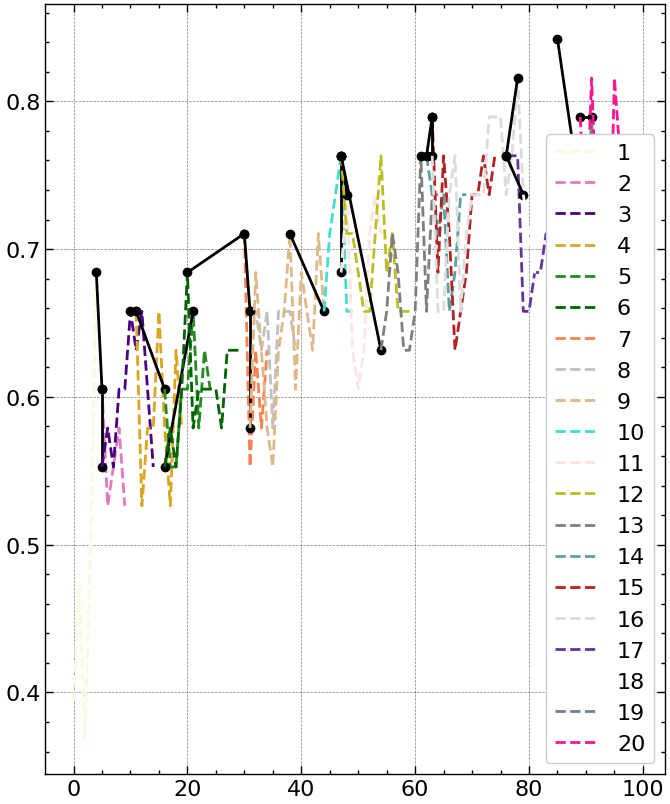

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))
# Assuming 'dfs' is a list of dataframes and each dataframe has 'epoch' and 'val_accuracy' columns
for c, df in enumerate(dfs):
    # Plot the main line with markers
    plt.plot(df.epoch, df.val_accuracy, '--', c=colors[c], label=str(c+1))

    # Find the index of the maximum val_accuracy in the current dataframe
    max_val_acc_index = df.val_accuracy.idxmax()

    # If this is not the last dataframe, draw a dotted line to the first point of the next dataframe
    if c < len(dfs) - 1:
        next_df = dfs[c + 1]
        # Get the point with max val_accuracy from the current dataframe and the first point of the next dataframe
        x_values = [df.epoch.iloc[max_val_acc_index], next_df.epoch.iloc[0]]
        y_values = [df.val_accuracy.iloc[max_val_acc_index], next_df.val_accuracy.iloc[0]]
        # Plot with dotted lines
        plt.plot(x_values, y_values, 'o-', color='black')

plt.legend()
plt.show()


In [ ]:
#TODO 
# make pipeline_3 notebook
# change increment epochs to 10
# colors from mcolors.TABLEAU_COLORS